# Baseball dataset

| Column         | Meaning                       |
| -------------- | ----------------------------- |
| `Team`         | Team abbreviation             |
| `League`       | American/National league      |
| `Year`         | Season year                   |
| `RS`           | Runs Scored                   |
| `RA`           | Runs Allowed                  |
| `W`            | Wins                          |
| `OBP`          | On-Base Percentage            |
| `SLG`          | Slugging Percentage           |
| `BA`           | Batting Average               |
| `Playoffs`     | Whether team reached playoffs |
| `RankSeason`   | Regular season rank           |
| `RankPlayoffs` | Playoff rank                  |
| `G`            | Games played                  |
| `OOBP`         | Opponent On-Base Percentage   |
| `OSLG`         | Opponent Slugging Percentage  |


In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/Users/apple/Documents/Python/datasets/baseball_stats.csv')


In [3]:
df.head(5)

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424


In [4]:
%%timeit
win_List = []

for i in range(len(df)):
    row = df.iloc[i]
    wins = row['W']
    game = row['G']
    cal = wins / game
    cal = np.round(cal,2)
    win_List.append(cal)

22.6 ms ± 110 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [6]:
win_List = []

for i in range(len(df)):
    row = df.iloc[i]
    wins = row['W']
    game = row['G']
    cal = wins / game
    cal = np.round(cal,2)
    win_List.append(cal)

In [7]:
len(win_List)

1232

In [8]:
win_List[1]

np.float64(0.58)

In [9]:
l = df.iterrows()

In [10]:
print(next(l))

(0, Team              ARI
League             NL
Year             2012
RS                734
RA                688
W                  81
OBP             0.328
SLG             0.418
BA              0.259
Playoffs            0
RankSeason        NaN
RankPlayoffs      NaN
G                 162
OOBP            0.317
OSLG            0.415
Name: 0, dtype: object)


In [11]:
%%timeit
win_List1 = []

for i, row in df.iterrows():
    wins = row['W']
    game = row['G']
    cal = wins / game
    cal = np.round(cal,2)
    win_List1.append(cal)

19.1 ms ± 67.6 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [12]:
win_List1 = []

for i, row in df.iterrows():
    wins = row['W']
    game = row['G']
    cal = wins / game
    cal = np.round(cal,2)
    win_List1.append(cal)

In [13]:
win_List1[1]

np.float64(0.58)

In [14]:
df['WP'] = win_List

In [15]:
df.head(3)

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG,WP
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415,0.50
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378,0.58
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403,0.57


In [16]:
for row_tuple in df.iterrows():
    print(row_tuple)
    print(type(row_tuple))

(0, Team              ARI
League             NL
Year             2012
RS                734
RA                688
W                  81
OBP             0.328
SLG             0.418
BA              0.259
Playoffs            0
RankSeason        NaN
RankPlayoffs      NaN
G                 162
OOBP            0.317
OSLG            0.415
WP                0.5
Name: 0, dtype: object)
<class 'tuple'>
(1, Team              ATL
League             NL
Year             2012
RS                700
RA                600
W                  94
OBP              0.32
SLG             0.389
BA              0.247
Playoffs            1
RankSeason        4.0
RankPlayoffs      5.0
G                 162
OOBP            0.306
OSLG            0.378
WP               0.58
Name: 1, dtype: object)
<class 'tuple'>
(2, Team              BAL
League             AL
Year             2012
RS                712
RA                705
W                  93
OBP             0.311
SLG             0.417
BA              0.247
Playof

In [35]:
def calc_run_diff(runs_scored, runs_allowed):

    run_diff = runs_scored - runs_allowed

    return run_diff

In [18]:
run_diffs = []

# Write a for loop and collect runs allowed and runs scored for each row
for i,row in df.iterrows():
    runs_scored = row['RS']
    runs_allowed = row['RA']
    
    # Use the provided function to calculate run_diff for each row
    run_diff = calc_run_diff(runs_scored, runs_allowed)
    
    # Append each run differential to the output list
    run_diffs.append(run_diff)

df['RD'] = run_diffs
df.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG,WP,RD
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415,0.50,46
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378,0.58,100
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403,0.57,7
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428,0.43,-72
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424,0.38,-146


In [19]:
Win_df = df[['Team','Year','W']]
Win_df

,Team,Year,W
0,ARI,2012,81
1,ATL,2012,94
2,BAL,2012,93
3,BOS,2012,69
4,CHC,2012,61
...,...,...,...
1227,PHI,1962,81
1228,PIT,1962,93
1229,SFG,1962,103
1230,STL,1962,84


Checking what is efficient 'iterrows' or 'itertuples'

We know iterrows() - gives us series of Tuples (index,data) -- becomes difficult if we only want the data -- takes more time

In [22]:
%%timeit
r = []
for row_tuple in Win_df.iterrows():
    r.append(row_tuple)

12.5 ms ± 134 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [28]:
#This is just to get an idea, timeit doesnt work with print

In [27]:

%%timeit
r = []
for row_tuple in Win_df.itertuples():
    r.append(row_tuple)

360 μs ± 9.72 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [30]:
# Loop over the DataFrame and print each row's Index, Year and Wins (W)
for row in df.itertuples():
  i = row.Index
  year = row.Year
  wins = row.W
  
  # Check if rangers made Playoffs (1 means yes; 0 means no)
  if row.Playoffs == 1:
    print(i, year, wins)

1 2012 94
2 2012 93
6 2012 97
9 2012 88
18 2012 95
19 2012 94
24 2012 94
25 2012 88
27 2012 93
29 2012 98
30 2011 94
39 2011 95
45 2011 96
48 2011 97
50 2011 102
55 2011 90
56 2011 91
57 2011 96
61 2010 91
66 2010 91
76 2010 94
78 2010 95
80 2010 97
84 2010 92
86 2010 96
87 2010 90
93 2009 95
98 2009 92
103 2009 97
104 2009 95
106 2009 87
108 2009 103
110 2009 93
115 2009 91
123 2008 95
124 2008 97
125 2008 89
133 2008 100
134 2008 84
135 2008 90
140 2008 92
146 2008 97
150 2007 90
153 2007 96
154 2007 85
157 2007 96
158 2007 90
163 2007 94
168 2007 94
170 2007 89
189 2006 95
194 2006 88
196 2006 96
197 2006 97
198 2006 97
199 2006 93
202 2006 88
205 2006 83
211 2005 90
213 2005 95
215 2005 99
221 2005 89
223 2005 95
228 2005 95
232 2005 82
235 2005 100
240 2004 92
242 2004 96
244 2004 98
252 2004 92
254 2004 93
256 2004 92
259 2004 101
266 2004 105
272 2003 101
274 2003 95
275 2003 88
281 2003 91
286 2003 90
289 2003 101
290 2003 96
295 2003 100
300 2002 99
301 2002 98
302 2002 101
31

# Avoid using Loops -- using .apply() functions (similar to pythons Map function) 

We will see how we can avoid the below loop, and replace it with .apply 
run_diffs = []

Write a for loop and collect runs allowed and runs scored for each row
for i,row in df.iterrows():
    runs_scored = row['RS']
    runs_allowed = row['RA']
    
    # Use the provided function to calculate run_diff for each row
    run_diff = calc_run_diff(runs_scored, runs_allowed)
    
    # Append each run differential to the output list
    run_diffs.append(run_diff)

df['RD'] = run_diffs
df.head()

In [33]:
#dropping column RD -- axis 1 -- is for column
df.drop('RD', axis = 1, inplace = True)
df.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG,WP
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415,0.50
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378,0.58
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403,0.57
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428,0.43
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424,0.38


# calculating difference of RS & RA with out iterating

In [37]:
# with .apply axis 1 -- rows {takes row values}
run_diffs = df.apply(
    lambda row: calc_run_diff(row['RS'],row['RA']), axis = 1
)
df['RD'] = run_diffs
df.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG,WP,RD
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415,0.50,46
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378,0.58,100
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403,0.57,7
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428,0.43,-72
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424,0.38,-146


In [43]:
nums_df = df.corr(numeric_only = True)


In [45]:
nums_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, Year to RD
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          15 non-null     float64
 1   RS            15 non-null     float64
 2   RA            15 non-null     float64
 3   W             15 non-null     float64
 4   OBP           15 non-null     float64
 5   SLG           15 non-null     float64
 6   BA            15 non-null     float64
 7   Playoffs      13 non-null     float64
 8   RankSeason    14 non-null     float64
 9   RankPlayoffs  14 non-null     float64
 10  G             15 non-null     float64
 11  OOBP          15 non-null     float64
 12  OSLG          15 non-null     float64
 13  WP            15 non-null     float64
 14  RD            15 non-null     float64
dtypes: float64(15)
memory usage: 2.4+ KB


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1232 entries, 0 to 1231
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Team          1232 non-null   object 
 1   League        1232 non-null   object 
 2   Year          1232 non-null   int64  
 3   RS            1232 non-null   int64  
 4   RA            1232 non-null   int64  
 5   W             1232 non-null   int64  
 6   OBP           1232 non-null   float64
 7   SLG           1232 non-null   float64
 8   BA            1232 non-null   float64
 9   Playoffs      1232 non-null   int64  
 10  RankSeason    244 non-null    float64
 11  RankPlayoffs  244 non-null    float64
 12  G             1232 non-null   int64  
 13  OOBP          420 non-null    float64
 14  OSLG          420 non-null    float64
 15  WP            1232 non-null   float64
 16  RD            1232 non-null   int64  
dtypes: float64(8), int64(7), object(2)
memory usage: 163.8+ KB


In [46]:
stat_df = df[['RS','RS','W','Playoffs']]

In [48]:
# Gather sum of all columns 
#axis is 0 - calculating the sum of all columns
stat_totals = stat_df.apply(sum, axis=0)
print(stat_totals)

RS          880981
RS          880981
W            99674
Playoffs       244
dtype: int64


In [49]:
stat_totals = stat_df.apply(sum, axis=1)
print(stat_totals)

0       1549
1       1495
2       1518
3       1537
4       1287
        ... 
1227    1491
1228    1505
1229    1860
1230    1632
1231    1258
Length: 1232, dtype: int64


In [51]:
type(stat_totals)

pandas.core.series.Series

# Optimal iterating using pandas internals

Pandas is built on numpy -- 
Hence we can use the broadcasting feature of numpy to vectorize the pandas calculation

In [52]:
#getting numpy values
win_np = df['W'].values
win_np

array([ 81,  94,  93, ..., 103,  84,  60], shape=(1232,))

In [53]:
type(win_np)

numpy.ndarray

## Adding a new column without iterating using .iloc or .iterrows() or .itertuples()

In [54]:
df.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG,WP,RD
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415,0.50,46
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378,0.58,100
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403,0.57,7
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428,0.43,-72
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424,0.38,-146


In [55]:
Run_totals = df['RS'] + df['RA']
df['RT'] = Run_totals

In [56]:
df.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG,WP,RD,RT
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415,0.50,46,1422
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378,0.58,100,1300
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403,0.57,7,1417
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428,0.43,-72,1540
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424,0.38,-146,1372


# Simple Vizualizations

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
win_ARI = df[df['Team'] == 'ARI']

In [60]:
win_ARI

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG,WP,RD,RT
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415,0.50,46,1422
30,ARI,NL,2011,731,662,94,0.322,0.413,0.250,1,5.0,4.0,162,0.316,0.409,0.58,69,1393
60,ARI,NL,2010,713,836,65,0.325,0.416,0.250,0,NaN,NaN,162,0.340,0.448,0.40,-123,1549
90,ARI,NL,2009,720,782,70,0.324,0.418,0.253,0,NaN,NaN,162,0.330,0.419,0.43,-62,1502
120,ARI,NL,2008,720,706,82,0.327,0.415,0.251,0,NaN,NaN,162,0.318,0.398,0.51,14,1426
150,ARI,NL,2007,712,732,90,0.321,0.413,0.250,1,3.0,3.0,162,0.334,0.420,0.56,-20,1444
180,ARI,NL,2006,773,788,76,0.331,0.424,0.267,0,NaN,NaN,162,0.335,0.431,0.47,-15,1561
210,ARI,NL,2005,696,856,77,0.332,0.421,0.256,0,NaN,NaN,162,0.345,0.455,0.48,-160,1552
241,ARI,NL,2004,615,899,51,0.310,0.393,0.253,0,NaN,NaN,162,0.350,0.439,0.31,-284,1514
271,ARI,NL,2003,717,685,84,0.330,0.417,0.263,0,NaN,NaN,162,0.322,0.388,0.52,32,1402


In [146]:
win_ARI = win_ARI.sort_values('Year')

In [70]:
win_ARI.head(5)

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG,WP,RD,RT
421,ARI,NL,1998,665,812,65,0.314,0.393,0.246,0,NaN,NaN,162,NaN,NaN,0.40,-147,1477
391,ARI,NL,1999,908,676,100,0.347,0.459,0.277,1,2.0,4.0,162,0.320,0.402,0.62,232,1584
361,ARI,NL,2000,792,754,85,0.333,0.429,0.265,0,NaN,NaN,162,0.326,0.424,0.52,38,1546
331,ARI,NL,2001,818,677,92,0.341,0.442,0.267,1,5.0,1.0,162,0.311,0.404,0.57,141,1495
301,ARI,NL,2002,819,674,98,0.346,0.423,0.267,1,4.0,4.0,162,0.305,0.397,0.60,145,1493


Task was destroyed but it is pending!
task: <Task pending name='Task-4002' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/apple/Desktop/Python/.venv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-4003' coro=<Kernel.shell_main() running at /Users/apple/Desktop/Python/.venv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/apple/Desktop/Python/.venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/apple/Desktop/Python/.venv/lib/python3.11/site-packages/matplotlib/artist.py:1199: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  with cbook._setattr_cm(self, eventson=False):
Task was destroyed but it is pending!
task: <Task pending name='Task-4003' coro=<Kernel.shell_main() running at /Users/apple/Desktop/Python/.venv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]

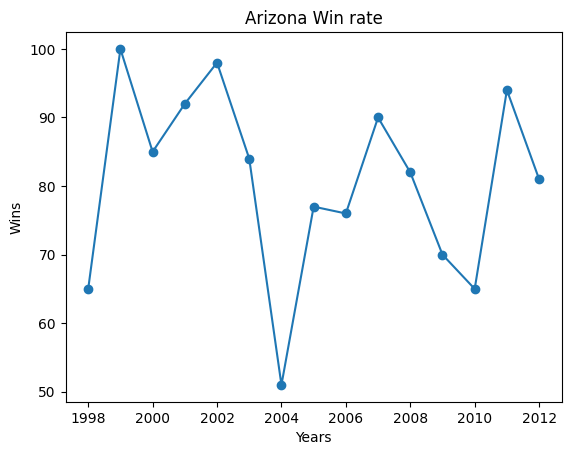

In [147]:
plt.plot(win_ARI['Year'], win_ARI['W'],marker = 'o')
plt.xlabel('Years')
plt.ylabel('Wins')
plt.title('Arizona Win rate')
plt.show()

In [73]:
df['Team'].unique()

array(['ARI', 'ATL', 'BAL', 'BOS', 'CHC', 'CHW', 'CIN', 'CLE', 'COL',
       'DET', 'HOU', 'KCR', 'LAA', 'LAD', 'MIA', 'MIL', 'MIN', 'NYM',
       'NYY', 'OAK', 'PHI', 'PIT', 'SDP', 'SEA', 'SFG', 'STL', 'TBR',
       'TEX', 'TOR', 'WSN', 'FLA', 'TBD', 'ANA', 'MON', 'CAL', 'WSA',
       'SEP', 'KCA', 'MLN'], dtype=object)

In [152]:
win_ATL = df[df['Team'] == 'ATL']
win_ATL = win_ATL.sort_values('Year')
win_ATL.count()

Team            43
League          43
Year            43
RS              43
RA              43
W               43
OBP             43
SLG             43
BA              43
Playoffs        43
RankSeason      17
RankPlayoffs    17
G               43
OOBP            14
OSLG            14
WP              43
RD              43
RT              43
dtype: int64

/var/folders/nh/crstfx8d3s12tbjvzszrk2700000gn/T/ipykernel_77280/4209681600.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


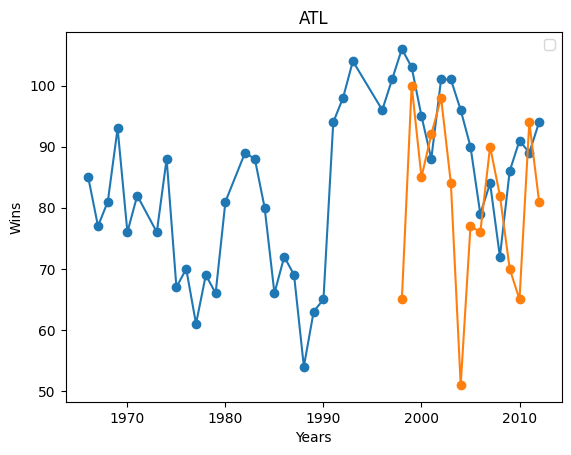

In [150]:
x = df['Year'].sort_values()
plt.plot(win_ATL['Year'], win_ATL['W'],marker = 'o')
plt.plot(win_ARI['Year'], win_ARI['W'],marker = 'o')
plt.xlabel('Years')
plt.ylabel('Wins')
plt.title('ATL')
plt.legend()
plt.show()

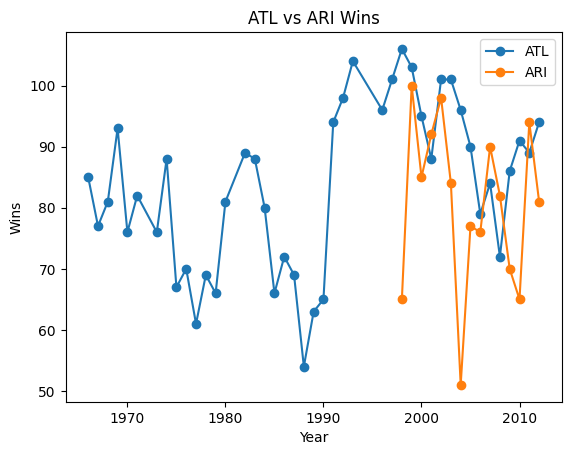

In [98]:
win_ATL = df[df['Team'] == 'ATL']
win_ATL = win_ATL.sort_values('Year')

win_ARI = df[df['Team'] == 'ARI']
win_ARI = win_ARI.sort_values('Year')

plt.plot(
    win_ATL['Year'],
    win_ATL['W'],
    marker='o',
    label='ATL'
)

plt.plot(
    win_ARI['Year'],
    win_ARI['W'],
    marker='o',
    label='ARI'
)

plt.xlabel('Year')
plt.ylabel('Wins')

plt.title('ATL vs ARI Wins')

plt.legend()

plt.show()

In [153]:
df.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG,WP,RD,RT
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415,0.50,46,1422
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378,0.58,100,1300
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403,0.57,7,1417
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428,0.43,-72,1540
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424,0.38,-146,1372


In [157]:
df['Team'].nunique()

39

In [172]:
strongest_team = df.groupby(['Team'])[['W','G']].mean()
strongest_team.head()

,W,G
Team,,
ANA,83.000000,162.000000
ARI,80.666667,162.000000
ATL,83.395349,161.837209
BAL,83.361702,161.680851
BOS,85.893617,161.787234


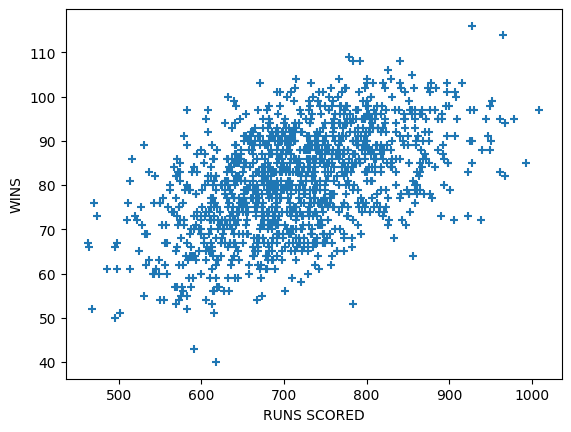

In [190]:
#more Run mean team win more games?  
plt.scatter(x = df['RS'], y =df['W'],marker = '+')
plt.xlabel('RUNS SCORED')
plt.ylabel('WINS')
plt.show()

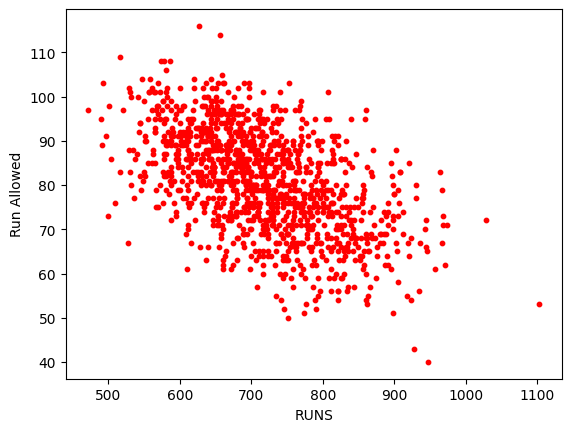

In [192]:
#team who fewer run, mean they win more game? 
plt.scatter(x = df['RA'], y =df['W'],marker = 'o',s=10,color='red')
plt.xlabel('RUNS')
plt.ylabel('Run Allowed')
plt.show()

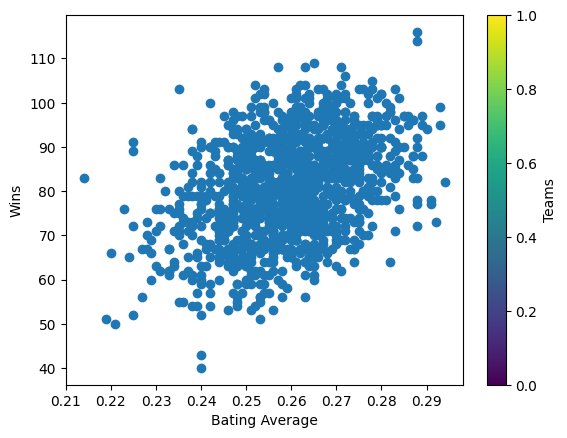

In [187]:
#Does bating averge relate to wim
plt.scatter(x = df['BA'], y =df['W'])
plt.xlabel('Bating Average')
plt.ylabel('Wins')
plt.colorbar(label='Teams')
plt.show()

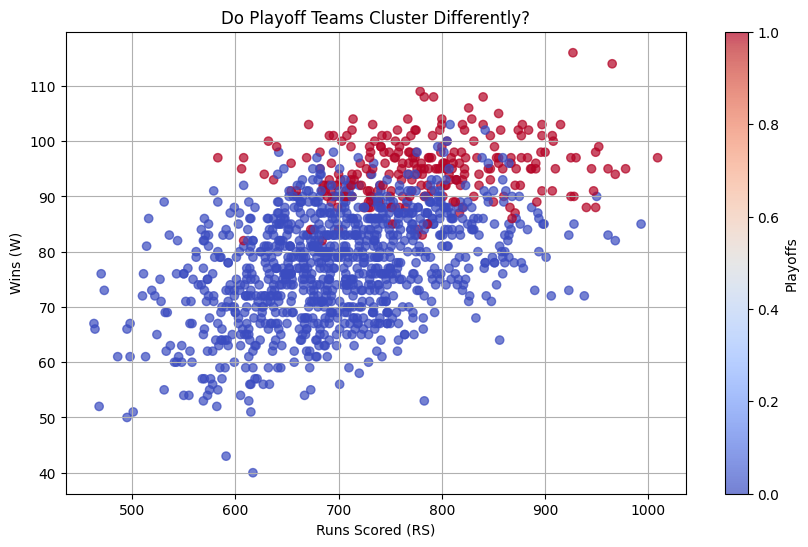

In [193]:
plt.figure(figsize=(10,6))

plt.scatter(
    x=df['RS'],
    y=df['W'],
    c=df['Playoffs'],   # 0 or 1 values
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel('Runs Scored (RS)')
plt.ylabel('Wins (W)')

plt.title('Do Playoff Teams Cluster Differently?')

plt.colorbar(label='Playoffs')

plt.grid(True)

plt.show()

In [194]:
df.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG,WP,RD,RT
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415,0.50,46,1422
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378,0.58,100,1300
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403,0.57,7,1417
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428,0.43,-72,1540
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424,0.38,-146,1372


In [204]:
winning_teams = df[(df['W'] >= 50)]
winning_teams

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG,WP,RD,RT
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415,0.50,46,1422
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378,0.58,100,1300
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403,0.57,7,1417
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428,0.43,-72,1540
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424,0.38,-146,1372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1227,PHI,NL,1962,705,759,81,0.330,0.390,0.260,0,NaN,NaN,161,NaN,NaN,0.50,-54,1464
1228,PIT,NL,1962,706,626,93,0.321,0.394,0.268,0,NaN,NaN,161,NaN,NaN,0.58,80,1332
1229,SFG,NL,1962,878,690,103,0.341,0.441,0.278,1,1.0,2.0,165,NaN,NaN,0.62,188,1568
1230,STL,NL,1962,774,664,84,0.335,0.394,0.271,0,NaN,NaN,163,NaN,NaN,0.52,110,1438


/var/folders/nh/crstfx8d3s12tbjvzszrk2700000gn/T/ipykernel_77280/4241024684.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Team', y='W', data = df, palette= 'Set2',showfliers=True)


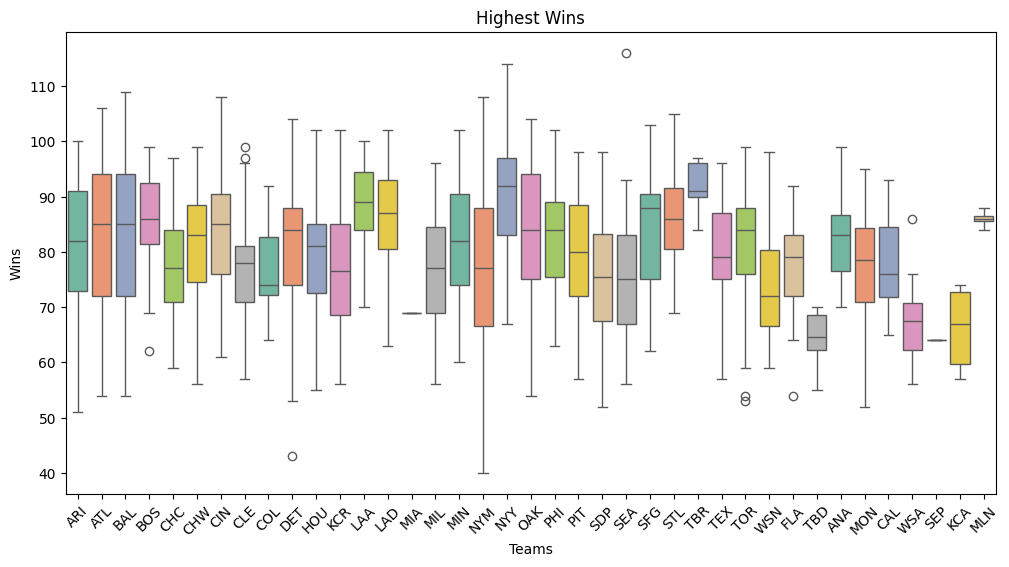

In [210]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Team', y='W', data = df, palette= 'Set2',showfliers=True)
plt.xticks(rotation = 45)
plt.xlabel('Teams')
plt.ylabel('Wins')
plt.title('Highest Wins')
plt.show()

In [211]:
df['League'].unique()

array(['NL', 'AL'], dtype=object)

/var/folders/nh/crstfx8d3s12tbjvzszrk2700000gn/T/ipykernel_77280/2044588909.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='League', y='RS', data = df, palette= 'viridis',showfliers=True)


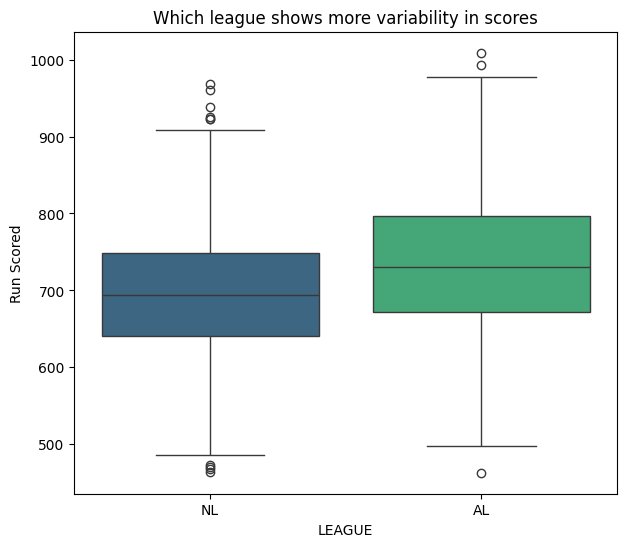

In [213]:
#Which League has more variability in Run Scored
plt.figure(figsize=(7,6))
sns.boxplot(x='League', y='RS', data = df, palette= 'viridis',showfliers=True)
#American/National league
plt.xlabel('LEAGUE')
plt.ylabel('Run Scored')
plt.title('Which league shows more variability in scores')
plt.show()

/var/folders/nh/crstfx8d3s12tbjvzszrk2700000gn/T/ipykernel_77280/1995410692.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='League', y='BA', data = df, palette= 'viridis',showfliers=True)


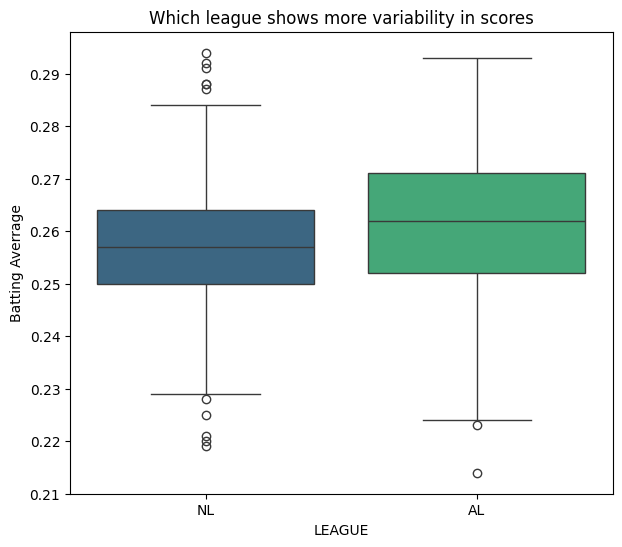

In [214]:
#Which League has more wider batting average
plt.figure(figsize=(7,6))
sns.boxplot(x='League', y='BA', data = df, palette= 'viridis',showfliers=True)
#American/National league
plt.xlabel('LEAGUE')
plt.ylabel('Batting Averrage')
plt.title('Which league shows more variability in scores')
plt.show()

/var/folders/nh/crstfx8d3s12tbjvzszrk2700000gn/T/ipykernel_77280/2775983613.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Team', y='BA', data = df, palette= 'coolwarm',showfliers=True)


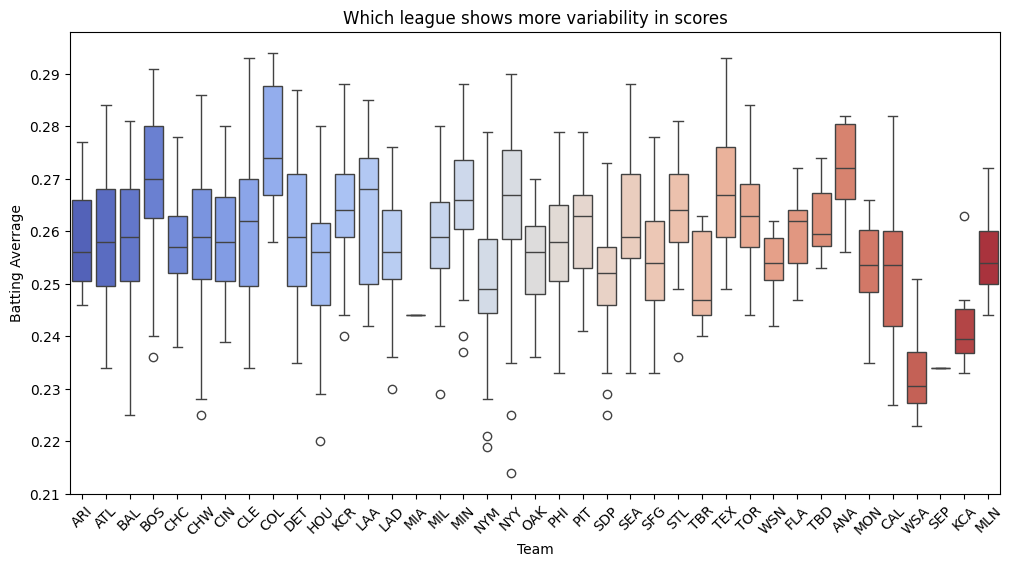

In [216]:
#Which Team has more wider batting average
plt.figure(figsize=(12,6))
sns.boxplot(x='Team', y='BA', data = df, palette= 'coolwarm',showfliers=True)
plt.xticks(rotation = 45)
plt.xlabel('Team')
plt.ylabel('Batting Averrage')
plt.title('Which league shows more variability in scores')
plt.show()

In [226]:
teams_win_rate = df.groupby('Team')['W'].sum()
teams_win_rate.values

array([ 664, 1210, 3586, 3918, 4037, 2189, 3639, 3838, 3949, 3642, 1371,
       3773, 1317, 3712,  397, 3093,  968, 4065,   69, 3036, 3841,  344,
       2485, 3637, 4242, 3448, 3869, 3736, 3029, 2492,   64, 3975, 4029,
        645,  458, 2958, 2680,  679,  590])

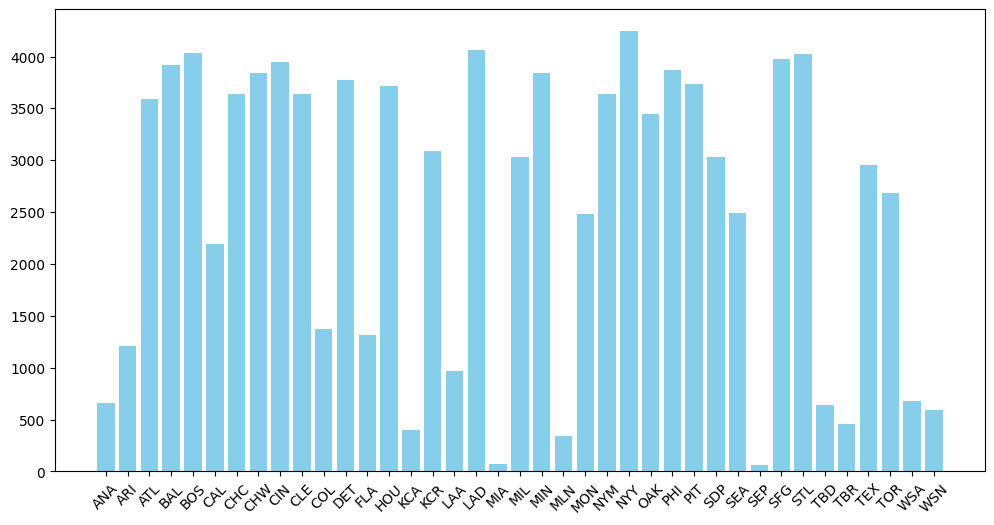

In [231]:

plt.bar(teams_win_rate.index, height = teams_win_rate.values,color = 'skyblue')
fig = plt.gcf()
fig.set_size_inches(12,6)
plt.xticks(rotation = 45)
plt.show()

In [247]:
Team_playoff = df.groupby('Team')['Playoffs'].count().reset_index() 
Team_playoff = Team_playoff.sort_values('Playoffs')
plt = Team_playoff['Playoffs']> 20
Team_playoff[plt].head(3)

,Team,Playoffs
5,CAL,28
22,MON,32
36,TOR,33
